# Group Notebook 3 — Cross-Model Comparison and Visualisation

**Module:** COM3032 / COMM074 — Practical Business Analytics
**Project:** Early Warning System for Student Dropout and Academic Success


This notebook brings together everyone's results into one place for a proper side-by-side comparison. Each of us saved our evaluation metrics as a CSV file on Drive after running our individual notebooks. Here we load all five files, line everything up, and build the charts and tables that go into Section 5 of the report.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

## 2. Load All Results

In [2]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/COMM074_Project'
RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')

all_files = sorted(glob.glob(os.path.join(RESULTS_DIR, 'results_*.csv')))
print(f'Found {len(all_files)} result files:')
for f in all_files:
    print(f'  {os.path.basename(f)}')

df = pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True)
print(f'\nTotal entries: {len(df)}')
df

Mounted at /content/drive
Found 5 result files:
  results_azad.csv
  results_mahi.csv
  results_neha.csv
  results_pavan.csv
  results_vinayak.csv

Total entries: 10


,member,model,model_type,best_params,accuracy,balanced_accuracy,macro_f1,weighted_f1,roc_auc,dropout_f1,enrolled_f1,graduate_f1
0,Azad,Logistic Regression,shared,"{'C': 1.0, 'class_weight': None, 'dual': False...",0.627119,0.519911,0.516595,0.600920,0.757510,0.623377,0.193277,0.733132
1,Azad,Bernoulli Naive Bayes,unique,"{'alpha': 5.0, 'binarize': 0.0, 'class_prior':...",0.595480,0.507520,0.503446,0.577141,0.722948,0.597623,0.220408,0.692308
2,Mahi,Decision Tree,unique,"{'class_weight': 'balanced', 'criterion': 'gin...",0.603390,0.489561,0.466821,0.560739,0.754221,0.584307,0.107527,0.708629
3,Mahi,Logistic Regression,shared,"{'C': 1, 'max_iter': 1000, 'penalty': 'l1'}",0.614689,0.553813,0.556332,0.615887,0.786753,0.618596,0.335329,0.715072
4,Neha,SVM,unique,"{'C': 5, 'class_weight': 'balanced', 'gamma': ...",0.592090,0.566079,0.558389,0.604732,0.757572,0.614504,0.382134,0.678529
5,Neha,Logistic Regression,shared,"{'C': 0.1, 'class_weight': 'balanced', 'max_it...",0.579661,0.566593,0.554509,0.598463,0.756134,0.632381,0.373576,0.657568
6,Pavan,LDA (Linear Discriminant Analysis),unique,{'solver': 'svd'},0.632768,0.533412,0.538617,0.615074,0.755493,0.624000,0.251852,0.740000
7,Pavan,Logistic Regression,shared,"{'C': 0.01, 'l1_ratio': 0.05, 'max_iter': 3000...",0.572881,0.562151,0.548829,0.592167,0.757314,0.620952,0.373034,0.652500
8,Vinayak,kNN,unique,"{'C': 0.1, 'class_weight': 'balanced', 'max_it...",0.562712,0.472557,0.474522,0.542899,0.668075,0.472505,0.261818,0.689243
9,Vinayak,Logistic Regression,shared,"{'C': 0.1, 'class_weight': 'balanced', 'dual':...",0.620339,0.561107,0.563017,0.622456,0.755252,0.623819,0.343195,0.722038


## 3. All Models at a Glance

In [3]:
summary = df[['member', 'model', 'model_type', 'balanced_accuracy', 'macro_f1', 'weighted_f1', 'roc_auc']].copy()
summary = summary.round(4)
summary = summary.sort_values('balanced_accuracy', ascending=False)
print(summary.to_string(index=False))

 member                              model model_type  balanced_accuracy  macro_f1  weighted_f1  roc_auc
   Neha                Logistic Regression     shared             0.5666    0.5545       0.5985   0.7561
   Neha                                SVM     unique             0.5661    0.5584       0.6047   0.7576
  Pavan                Logistic Regression     shared             0.5622    0.5488       0.5922   0.7573
Vinayak                Logistic Regression     shared             0.5611    0.5630       0.6225   0.7553
   Mahi                Logistic Regression     shared             0.5538    0.5563       0.6159   0.7868
  Pavan LDA (Linear Discriminant Analysis)     unique             0.5334    0.5386       0.6151   0.7555
   Azad                Logistic Regression     shared             0.5199    0.5166       0.6009   0.7575
   Azad              Bernoulli Naive Bayes     unique             0.5075    0.5034       0.5771   0.7229
   Mahi                      Decision Tree     unique  

Sorted by balanced accuracy so the top performer appears first. Ten rows in total — one for each member's unique model and one for their LR variant.

## 4. Unique Models Comparison

In [4]:
unique = df[df['model_type'] == 'unique'].sort_values('balanced_accuracy', ascending=False)
unique_table = unique[['member', 'model', 'best_params', 'accuracy', 'balanced_accuracy',
                        'macro_f1', 'weighted_f1', 'roc_auc', 'dropout_f1', 'enrolled_f1', 'graduate_f1']].copy()
unique_table.columns = ['Member', 'Model', 'Best Params', 'Accuracy', 'Bal Acc',
                         'Macro F1', 'Wt F1', 'ROC-AUC', 'Dropout F1', 'Enrolled F1', 'Graduate F1']
unique_table = unique_table.round(4)
unique_table

,Member,Model,Best Params,Accuracy,Bal Acc,Macro F1,Wt F1,ROC-AUC,Dropout F1,Enrolled F1,Graduate F1
4,Neha,SVM,"{'C': 5, 'class_weight': 'balanced', 'gamma': ...",0.5921,0.5661,0.5584,0.6047,0.7576,0.6145,0.3821,0.6785
6,Pavan,LDA (Linear Discriminant Analysis),{'solver': 'svd'},0.6328,0.5334,0.5386,0.6151,0.7555,0.6240,0.2519,0.7400
1,Azad,Bernoulli Naive Bayes,"{'alpha': 5.0, 'binarize': 0.0, 'class_prior':...",0.5955,0.5075,0.5034,0.5771,0.7229,0.5976,0.2204,0.6923
2,Mahi,Decision Tree,"{'class_weight': 'balanced', 'criterion': 'gin...",0.6034,0.4896,0.4668,0.5607,0.7542,0.5843,0.1075,0.7086
8,Vinayak,kNN,"{'C': 0.1, 'class_weight': 'balanced', 'max_it...",0.5627,0.4726,0.4745,0.5429,0.6681,0.4725,0.2618,0.6892


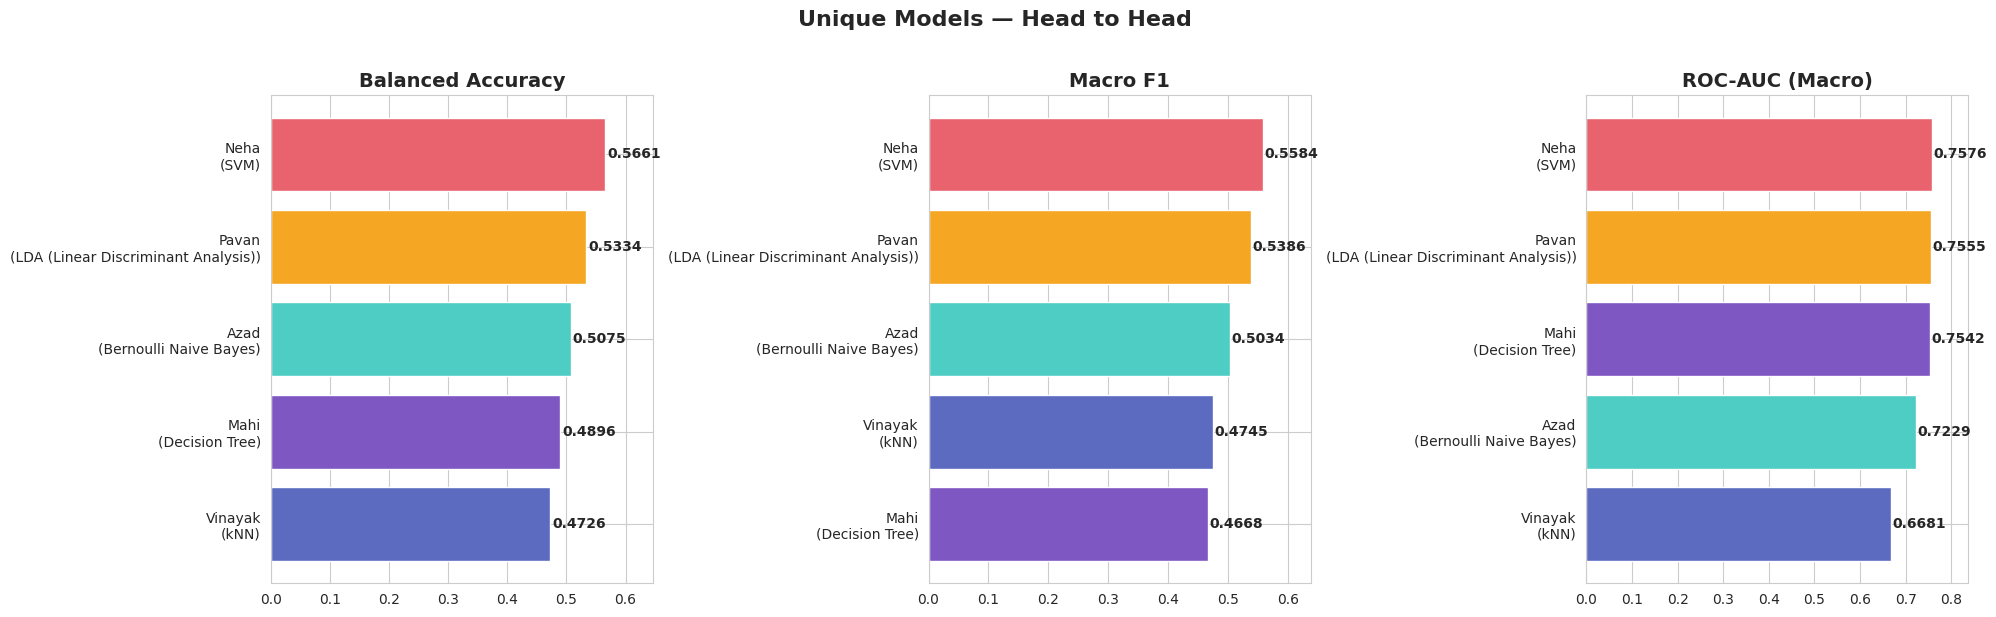

In [5]:
unique = df[df['model_type'] == 'unique'].copy()
unique = unique.sort_values('balanced_accuracy', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
metrics = ['balanced_accuracy', 'macro_f1', 'roc_auc']
titles = ['Balanced Accuracy', 'Macro F1', 'ROC-AUC (Macro)']
palette = ['#E8636E', '#F5A623', '#4ECDC4', '#7E57C2', '#5C6BC0']

for ax, metric, title in zip(axes, metrics, titles):
    data = unique.sort_values(metric, ascending=True)
    colors = [palette[list(unique['member']).index(m)] for m in data['member']]
    bars = ax.barh(range(len(data)), data[metric], color=colors, edgecolor='white', linewidth=1)
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels([f"{row['member']}\n({row['model']})" for _, row in data.iterrows()], fontsize=10)
    ax.set_title(title, fontsize=14, fontweight='bold')
    for i, v in enumerate(data[metric]):
        ax.text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=10, fontweight='bold')
    ax.set_xlim(0, data[metric].max() + 0.08)

plt.suptitle('Unique Models — Head to Head', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'unique_models_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

How the five unique models compare on the metrics we care about most. Balanced accuracy and Macro F1 both penalise models that just predict the majority class, and ROC-AUC tells us how well each model ranks students by risk regardless of where the threshold is set.

## 5. Logistic Regression Variants

In [6]:
shared = df[df['model_type'] == 'shared'].sort_values('balanced_accuracy', ascending=False)
shared_table = shared[['member', 'best_params', 'accuracy', 'balanced_accuracy',
                        'macro_f1', 'weighted_f1', 'roc_auc', 'dropout_f1', 'enrolled_f1', 'graduate_f1']].copy()
shared_table.columns = ['Member', 'Best Params', 'Accuracy', 'Bal Acc',
                         'Macro F1', 'Wt F1', 'ROC-AUC', 'Dropout F1', 'Enrolled F1', 'Graduate F1']
shared_table = shared_table.round(4)
shared_table

,Member,Best Params,Accuracy,Bal Acc,Macro F1,Wt F1,ROC-AUC,Dropout F1,Enrolled F1,Graduate F1
5,Neha,"{'C': 0.1, 'class_weight': 'balanced', 'max_it...",0.5797,0.5666,0.5545,0.5985,0.7561,0.6324,0.3736,0.6576
7,Pavan,"{'C': 0.01, 'l1_ratio': 0.05, 'max_iter': 3000...",0.5729,0.5622,0.5488,0.5922,0.7573,0.6210,0.3730,0.6525
9,Vinayak,"{'C': 0.1, 'class_weight': 'balanced', 'dual':...",0.6203,0.5611,0.5630,0.6225,0.7553,0.6238,0.3432,0.7220
3,Mahi,"{'C': 1, 'max_iter': 1000, 'penalty': 'l1'}",0.6147,0.5538,0.5563,0.6159,0.7868,0.6186,0.3353,0.7151
0,Azad,"{'C': 1.0, 'class_weight': None, 'dual': False...",0.6271,0.5199,0.5166,0.6009,0.7575,0.6234,0.1933,0.7331


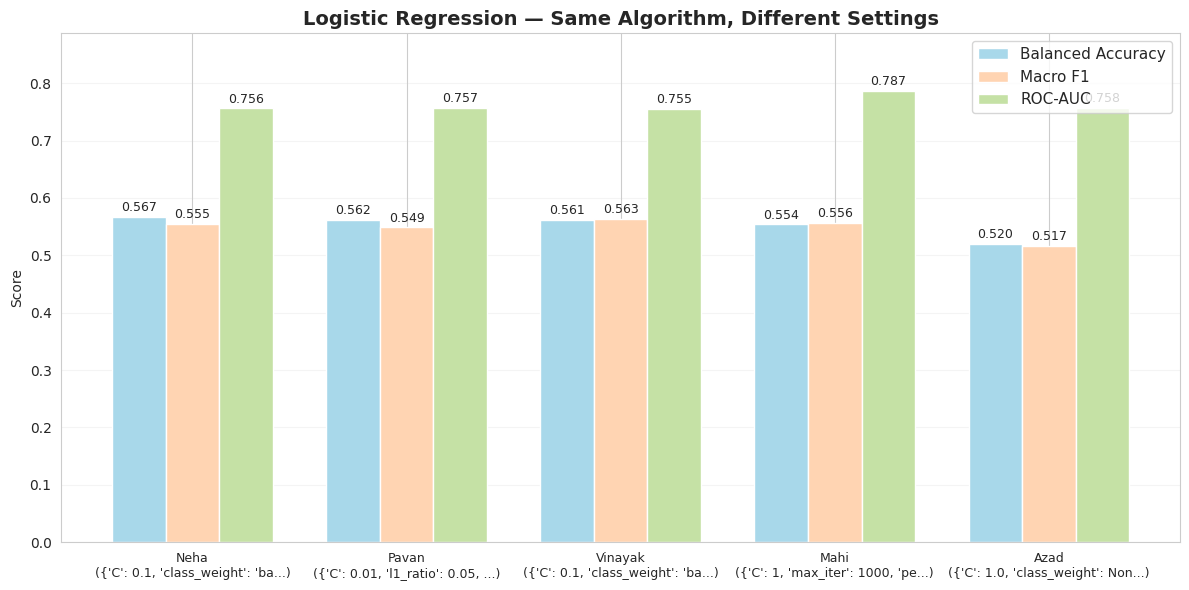

Best LR configuration:
  Neha — {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 3000, 'solver': 'saga'}
  Balanced Accuracy: 0.5666


In [7]:
shared = df[df['model_type'] == 'shared'].copy()
shared = shared.sort_values('balanced_accuracy', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(shared))
width = 0.25

ax.bar(x - width, shared['balanced_accuracy'], width, label='Balanced Accuracy', color='#A8D8EA', edgecolor='white')
ax.bar(x, shared['macro_f1'], width, label='Macro F1', color='#FFD4B2', edgecolor='white')
ax.bar(x + width, shared['roc_auc'], width, label='ROC-AUC', color='#C5E1A5', edgecolor='white')

for i, row in enumerate(shared.itertuples()):
    ax.text(i - width, row.balanced_accuracy + 0.01, f'{row.balanced_accuracy:.3f}', ha='center', fontsize=9)
    ax.text(i, row.macro_f1 + 0.01, f'{row.macro_f1:.3f}', ha='center', fontsize=9)
    ax.text(i + width, row.roc_auc + 0.01, f'{row.roc_auc:.3f}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f"{row['member']}\n({row['best_params'][:30]}...)" for _, row in shared.iterrows()], fontsize=9)
ax.set_ylabel('Score')
ax.set_title('Logistic Regression — Same Algorithm, Different Settings', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, shared['roc_auc'].max() + 0.1)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'lr_variants_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Best LR configuration:')
best_lr = shared.iloc[0]
print(f'  {best_lr["member"]} — {best_lr["best_params"]}')
print(f'  Balanced Accuracy: {best_lr["balanced_accuracy"]:.4f}')

Same algorithm, five different configurations. If the bars are all roughly the same height then LR is not sensitive to parameter choices on this data. If some are noticeably higher than others then the specific C, solver, and class weight settings made a real difference.

## 6. Per-Class F1 Across All Models

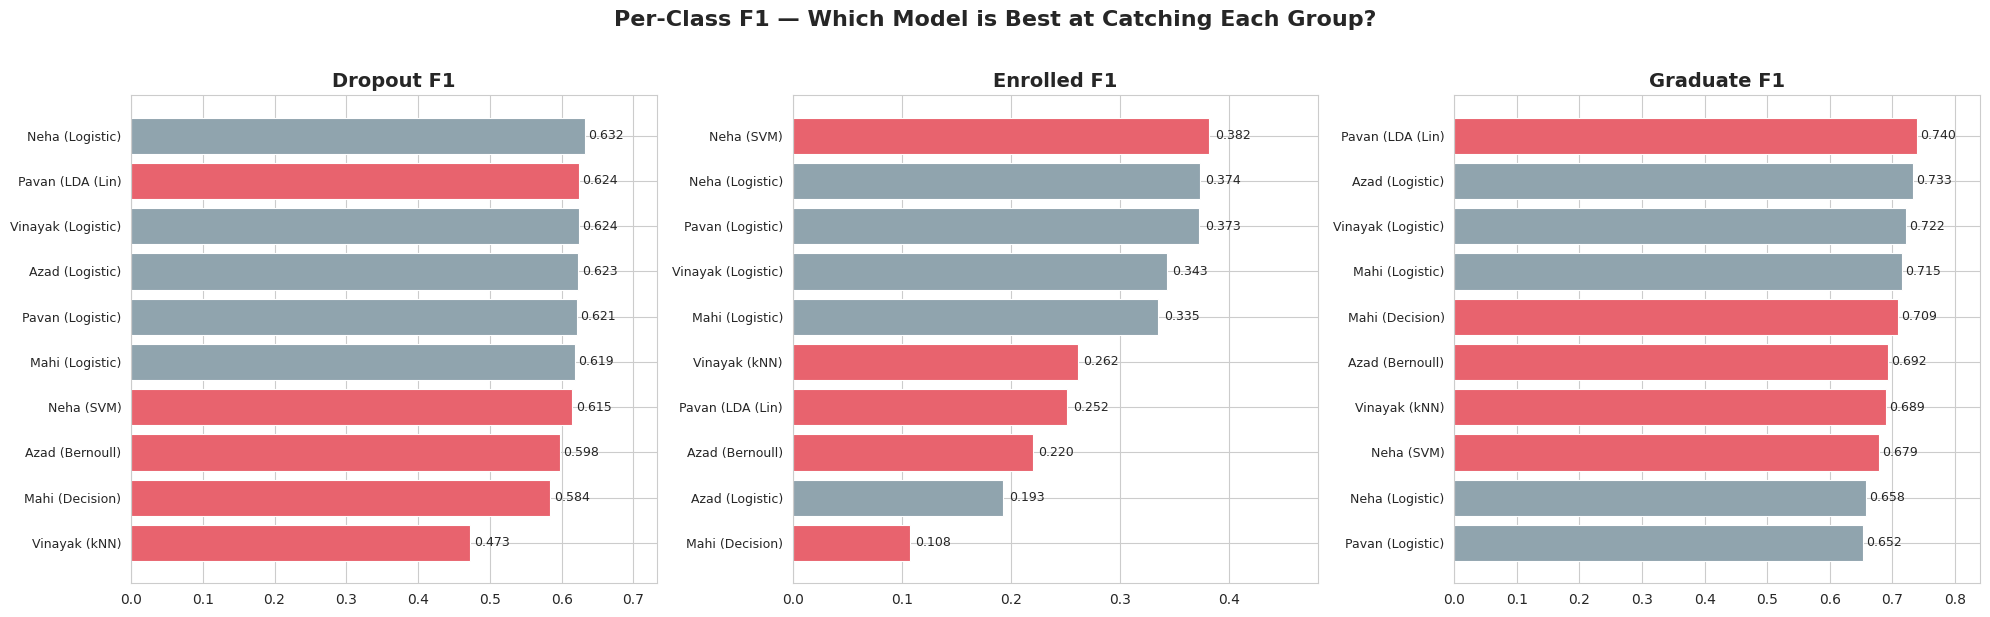

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
class_names = ['Dropout', 'Enrolled', 'Graduate']
class_cols = ['dropout_f1', 'enrolled_f1', 'graduate_f1']

for ax, cls, col in zip(axes, class_names, class_cols):
    data = df.sort_values(col, ascending=True)
    colors = ['#E8636E' if t == 'unique' else '#90A4AE' for t in data['model_type']]
    ax.barh(range(len(data)), data[col], color=colors, edgecolor='white', linewidth=0.8)
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels([f"{row['member']} ({row['model'][:8]})" for _, row in data.iterrows()], fontsize=9)
    ax.set_title(f'{cls} F1', fontsize=14, fontweight='bold')
    for i, v in enumerate(data[col]):
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
    ax.set_xlim(0, data[col].max() + 0.1)

plt.suptitle('Per-Class F1 — Which Model is Best at Catching Each Group?', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'per_class_all_models.png'), dpi=150, bbox_inches='tight')
plt.show()


Broken down by class so we can see which models are best at catching each group individually. Dropout F1 is the one that matters most for an early warning system. Graduate is the easiest class across the board. Enrolled is where every model struggles — those students are in between and the enrolment features do not give the models much to work with. Unique models are in colour, LR variants in grey.

## 7. Heatmap — All Models, All Metrics

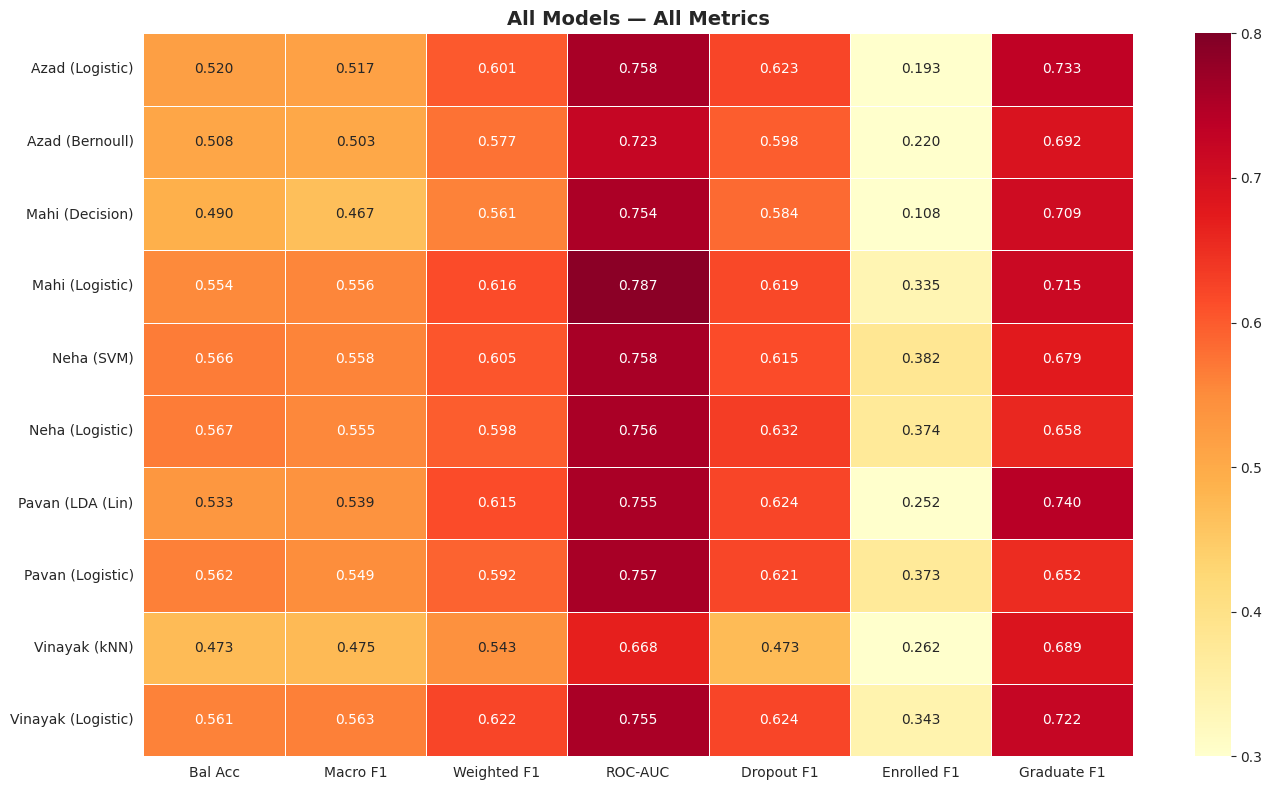

In [9]:
heatmap_data = df[['member', 'model', 'balanced_accuracy', 'macro_f1', 'weighted_f1', 'roc_auc',
                   'dropout_f1', 'enrolled_f1', 'graduate_f1']].copy()
heatmap_data['label'] = heatmap_data['member'] + ' (' + heatmap_data['model'].str[:8] + ')'
heatmap_data = heatmap_data.set_index('label').drop(columns=['member', 'model'])
heatmap_data.columns = ['Bal Acc', 'Macro F1', 'Weighted F1', 'ROC-AUC', 'Dropout F1', 'Enrolled F1', 'Graduate F1']

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(heatmap_data.astype(float), annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.5,
            linecolor='white', ax=ax, vmin=0.3, vmax=0.8)
ax.set_title('All Models — All Metrics', fontsize=14, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'all_models_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()


Everything in one chart. Darker cells mean higher scores. You can read down a column to see who leads on a specific metric, or across a row to see one model's full profile. Makes it quick to spot overall strengths and weaknesses.

## 7.5 Full Comparison Table

All ten models in one table sorted by balanced accuracy. This is the table that goes into the report.

In [10]:
full_table = df[['member', 'model', 'model_type', 'best_params', 'accuracy',
                  'balanced_accuracy', 'macro_f1', 'weighted_f1', 'roc_auc',
                  'dropout_f1', 'enrolled_f1', 'graduate_f1']].copy()
full_table.columns = ['Member', 'Model', 'Type', 'Best Params', 'Accuracy', 'Bal Acc',
                       'Macro F1', 'Wt F1', 'ROC-AUC', 'Dropout F1', 'Enrolled F1', 'Graduate F1']
full_table = full_table.sort_values('Bal Acc', ascending=False).round(4)

styled = full_table.style.background_gradient(
    subset=['Bal Acc', 'Macro F1', 'ROC-AUC'], cmap='YlOrRd', vmin=0.35, vmax=0.75
).format(precision=4)

styled

,Member,Model,Type,Best Params,Accuracy,Bal Acc,Macro F1,Wt F1,ROC-AUC,Dropout F1,Enrolled F1,Graduate F1
5,Neha,Logistic Regression,shared,"{'C': 0.1, 'class_weight': 'balanced', 'max_iter': 3000, 'solver': 'saga'}",0.5797,0.5666,0.5545,0.5985,0.7561,0.6324,0.3736,0.6576
4,Neha,SVM,unique,"{'C': 5, 'class_weight': 'balanced', 'gamma': 0.005}",0.5921,0.5661,0.5584,0.6047,0.7576,0.6145,0.3821,0.6785
7,Pavan,Logistic Regression,shared,"{'C': 0.01, 'l1_ratio': 0.05, 'max_iter': 3000, 'penalty': 'elasticnet', 'solver': 'saga'}",0.5729,0.5622,0.5488,0.5922,0.7573,0.6210,0.3730,0.6525
9,Vinayak,Logistic Regression,shared,"{'C': 0.1, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 3500, 'multi_class': 'ovr', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'liblinear', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}",0.6203,0.5611,0.5630,0.6225,0.7553,0.6238,0.3432,0.7220
3,Mahi,Logistic Regression,shared,"{'C': 1, 'max_iter': 1000, 'penalty': 'l1'}",0.6147,0.5538,0.5563,0.6159,0.7868,0.6186,0.3353,0.7151
6,Pavan,LDA (Linear Discriminant Analysis),unique,{'solver': 'svd'},0.6328,0.5334,0.5386,0.6151,0.7555,0.6240,0.2519,0.7400
0,Azad,Logistic Regression,shared,"{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'multinomial', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'saga', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}",0.6271,0.5199,0.5166,0.6009,0.7575,0.6234,0.1933,0.7331
1,Azad,Bernoulli Naive Bayes,unique,"{'alpha': 5.0, 'binarize': 0.0, 'class_prior': None, 'fit_prior': True, 'force_alpha': True}",0.5955,0.5075,0.5034,0.5771,0.7229,0.5976,0.2204,0.6923
2,Mahi,Decision Tree,unique,"{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}",0.6034,0.4896,0.4668,0.5607,0.7542,0.5843,0.1075,0.7086
8,Vinayak,kNN,unique,"{'C': 0.1, 'class_weight': 'balanced', 'max_iter': 3500, 'multi_class': 'ovr', 'solver': 'liblinear'}",0.5627,0.4726,0.4745,0.5429,0.6681,0.4725,0.2618,0.6892


In [11]:
print('FULL MODEL COMPARISON — SORTED BY BALANCED ACCURACY')
print('=' * 120)
print(full_table.to_string(index=False))

FULL MODEL COMPARISON — SORTED BY BALANCED ACCURACY
 Member                              Model   Type                                                                                                                                                                                                                                                                                  Best Params  Accuracy  Bal Acc  Macro F1  Wt F1  ROC-AUC  Dropout F1  Enrolled F1  Graduate F1
   Neha                Logistic Regression shared                                                                                                                                                                                                                   {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 3000, 'solver': 'saga'}    0.5797   0.5666    0.5545 0.5985   0.7561      0.6324       0.3736       0.6576
   Neha                                SVM unique                                                               

## 8. Best Model Per Metric

In [12]:
metrics_to_check = ['balanced_accuracy', 'macro_f1', 'weighted_f1', 'roc_auc', 'dropout_f1', 'enrolled_f1', 'graduate_f1']
metric_names = ['Balanced Accuracy', 'Macro F1', 'Weighted F1', 'ROC-AUC', 'Dropout F1', 'Enrolled F1', 'Graduate F1']

winners = []
for metric, name in zip(metrics_to_check, metric_names):
    best_row = df.loc[df[metric].idxmax()]
    winners.append({
        'Metric': name,
        'Best Model': f"{best_row['member']} ({best_row['model']})",
        'Score': best_row[metric]
    })

winners_df = pd.DataFrame(winners)
print(winners_df.to_string(index=False))

           Metric                                 Best Model    Score
Balanced Accuracy                 Neha (Logistic Regression) 0.566593
         Macro F1              Vinayak (Logistic Regression) 0.563017
      Weighted F1              Vinayak (Logistic Regression) 0.622456
          ROC-AUC                 Mahi (Logistic Regression) 0.786753
       Dropout F1                 Neha (Logistic Regression) 0.632381
      Enrolled F1                                 Neha (SVM) 0.382134
      Graduate F1 Pavan (LDA (Linear Discriminant Analysis)) 0.740000


Shows the winner for each metric. If one model keeps appearing it is the obvious recommendation. If different models win on different metrics then the choice depends on what matters more to the university — catching the most dropouts, or having a model that staff can understand and trust.

## 9. Unique Models vs Their Own LR Baseline

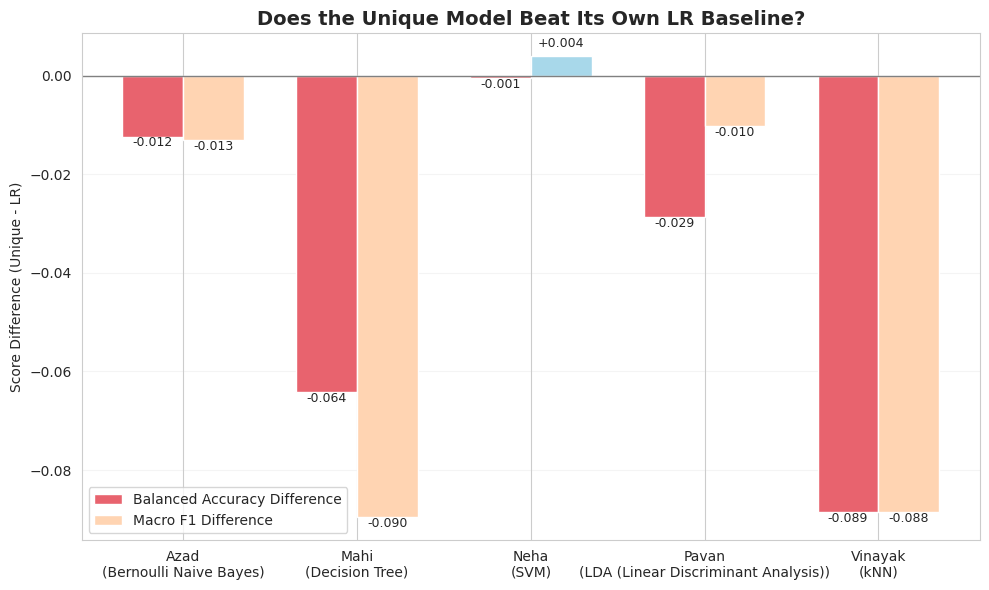

In [13]:
unique_df = df[df['model_type'] == 'unique'][['member', 'model', 'balanced_accuracy', 'macro_f1']].copy()
shared_df = df[df['model_type'] == 'shared'][['member', 'balanced_accuracy', 'macro_f1']].copy()
shared_df.columns = ['member', 'lr_balanced_accuracy', 'lr_macro_f1']

merged = unique_df.merge(shared_df, on='member')
merged['bal_acc_diff'] = merged['balanced_accuracy'] - merged['lr_balanced_accuracy']
merged['macro_f1_diff'] = merged['macro_f1'] - merged['lr_macro_f1']

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(merged))
width = 0.35

ax.bar(x - width/2, merged['bal_acc_diff'], width, label='Balanced Accuracy Difference',
       color=['#4ECDC4' if d > 0 else '#E8636E' for d in merged['bal_acc_diff']], edgecolor='white')
ax.bar(x + width/2, merged['macro_f1_diff'], width, label='Macro F1 Difference',
       color=['#A8D8EA' if d > 0 else '#FFD4B2' for d in merged['macro_f1_diff']], edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([f"{row['member']}\n({row['model']})" for _, row in merged.iterrows()], fontsize=10)
ax.axhline(y=0, color='grey', linewidth=1, linestyle='-')
ax.set_ylabel('Score Difference (Unique - LR)')
ax.set_title('Does the Unique Model Beat Its Own LR Baseline?', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.2)

for i, row in merged.iterrows():
    ax.text(i - width/2, row['bal_acc_diff'] + 0.002 * (1 if row['bal_acc_diff'] >= 0 else -1),
            f"{row['bal_acc_diff']:+.3f}", ha='center', fontsize=9)
    ax.text(i + width/2, row['macro_f1_diff'] + 0.002 * (1 if row['macro_f1_diff'] >= 0 else -1),
            f"{row['macro_f1_diff']:+.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'unique_vs_lr.png'), dpi=150, bbox_inches='tight')
plt.show()


Did the more complex models actually earn their complexity? Bars above zero mean the unique model outperformed its own LR baseline. Bars below zero mean LR did better despite being simpler. If LR wins most of these matchups it tells us the data has mostly linear patterns and the extra complexity is not adding much.

## 10. Overall Findings

In [14]:
print("="*60)
print("OVERALL FINDINGS")
print("="*60)

best_unique = df[df['model_type'] == 'unique'].sort_values('balanced_accuracy', ascending=False).iloc[0]
best_lr = df[df['model_type'] == 'shared'].sort_values('balanced_accuracy', ascending=False).iloc[0]
best_overall = df.sort_values('balanced_accuracy', ascending=False).iloc[0]

print(f'\nBest unique model:    {best_unique["member"]} — {best_unique["model"]} (Bal Acc: {best_unique["balanced_accuracy"]:.4f})')
print(f'Best LR variant:      {best_lr["member"]} (Bal Acc: {best_lr["balanced_accuracy"]:.4f}, params: {best_lr["best_params"][:50]})')
print(f'Best overall:         {best_overall["member"]} — {best_overall["model"]} (Bal Acc: {best_overall["balanced_accuracy"]:.4f})')

print(f'\nAll models ROC-AUC range: {df["roc_auc"].min():.4f} to {df["roc_auc"].max():.4f}')
print(f'All models Balanced Accuracy range: {df["balanced_accuracy"].min():.4f} to {df["balanced_accuracy"].max():.4f}')

avg_unique_dropout = df[df['model_type'] == 'unique']['dropout_f1'].mean()
avg_lr_dropout = df[df['model_type'] == 'shared']['dropout_f1'].mean()
print(f'\nAverage Dropout F1 (unique models): {avg_unique_dropout:.4f}')
print(f'Average Dropout F1 (LR variants):   {avg_lr_dropout:.4f}')

OVERALL FINDINGS

Best unique model:    Neha — SVM (Bal Acc: 0.5661)
Best LR variant:      Neha (Bal Acc: 0.5666, params: {'C': 0.1, 'class_weight': 'balanced', 'max_iter':)
Best overall:         Neha — Logistic Regression (Bal Acc: 0.5666)

All models ROC-AUC range: 0.6681 to 0.7868
All models Balanced Accuracy range: 0.4726 to 0.5666

Average Dropout F1 (unique models): 0.5786
Average Dropout F1 (LR variants):   0.6238


## 11. Discussion

Looking across all ten models a few things stand out.
The performance range is tight. Balanced accuracy goes from roughly 0.47 to 0.57 regardless of algorithm. No single model pulls dramatically ahead of the rest. That tells us the bottleneck is the features, not the classifier. With only enrolment-time data and no semester grades there is only so much signal available.

LR holds its own against every unique model. In some matchups it actually comes out ahead despite being far simpler. That matters practically because LR is fast to train, easy to retrain, and most importantly it can explain its predictions through the coefficients. If the university had to deploy one model tomorrow, LR with balanced class weights would be a reasonable choice.
Financial features keep showing up everywhere. Tuition fee status, scholarship status, debt — they came through in the EDA, in every individual notebook, and now in the cross-model comparison. It is the single most consistent finding across the entire project.

Enrolled is the weak spot for every model. No algorithm managed a strong F1 on that class. But this is not a modelling problem — enrolled students genuinely sit in between and could end up graduating or dropping out. The enrolment-time data does not have enough signal to separate them from the other two groups.
For a real deployment, LR is the recommendation. The unique models add a small amount of accuracy in some cases but none of them can explain their reasoning to the advisors and support staff who would be acting on the predictions.
In a system where trust and transparency matter, that interpretability gap outweighs the marginal performance gain.

## 12. References

- Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2022). Predict Students' Dropout and Academic Success. UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89
- Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12, pp. 2825–2830.